# Charts for SW QTSA model results
Compatible with Qiskit 1.2.4+

### Author
- **Jacob Cybulski**, jacob.cybulski[at]deakin.edu.au<br/>
    School of IT, SEBE, Deakin University, Melbourne, Vic, Australia

### Date
- Oct 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation. In association with IEEE Conference Trends in Quantum Computing and Emerging Business Technologies - TQCEBT 2022
- May 2024: Compatibility upgrade to Qiskit 1.2.4+
- Feb 2025: Addition of model instances

### Aims
> *This script aims to analyse history of training an overloading quantum neural network with sliding-windows of time-series data.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

In [1]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.',
 '..']

In [2]:
import os
import numpy as np
import pylab
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Window import *
from utils.Charts import *
from utils.Files import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Listing control
debug = True
seed = 2022

### Software version
MAJOR = 9
MINOR = 12

### Constants
LOG_NAME = '../log_4_iter'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('../log_4_iter',
 '2_sins_sw',
 '../log_4_iter/data',
 '../log_4_iter/training',
 '../log_4_iter/analysis',
 '../log_4_iter/figures')

## Fetch all training meta-data
**<font color="red">Enter the name of the DATA_ID</font>**<br/>
*Note that this is windowed TS data (as indicated by "sw" in the data ID)*

In [4]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [5]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [6]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



## Fetch all training meta-data
**<font color="red">Enter the name of the TRAIN_ID</font>**

In [7]:
### Training parameters

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   l: number of layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs
TRAIN_ID = '2_sins_sw_cnn_n70_z0_hl150_100_050_LBFGS_ep60'
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/info.json'
train_info_fpath

'../log_4_iter/training/2_sins_sw_cnn_n70_z0_hl150_100_050_LBFGS_ep60/info.json'

In [8]:
## Fetch all training parameters
train_info = read_json_file(train_info_fpath)

print(f'\nLoaded QTSA from a file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
    # print(f"{k} = train_info['{k}']")
print()

CASE_NAME = train_info['case_name']
MAJOR = train_info['major_version']
MINOR = train_info['minor_version']
DATA_NAME = train_info['data_name']
samples = train_info['data_sample']
train_pc = train_info['data_split']
noise = train_info['data_noise']
inputs = train_info['model_inputs']
layers = train_info['model_layers']
outputs = train_info['model_outputs']
log_interv = train_info['log_interv']
opt_name = train_info['opt_name']
epochs = train_info['epochs']
seed = train_info['seed']
inst_no = train_info['inst_no']
inst_seeds = train_info['inst_seeds']


Loaded QTSA from a file "../log_4_iter/training/2_sins_sw_cnn_n70_z0_hl150_100_050_LBFGS_ep60/info.json":

	info[case_name] = cnn
	info[major_version] = 9
	info[minor_version] = 13
	info[data_name] = 2_sins_sw
	info[data_sample] = 70
	info[data_split] = 0.7142857142857143
	info[data_noise] = 0
	info[model_inputs] = 5
	info[model_layers] = [150, 100, 50]
	info[model_outputs] = 1
	info[log_interv] = 1
	info[opt_name] = LBFGS
	info[epochs] = 60
	info[seed] = 2022
	info[inst_no] = 10
	info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Plot data

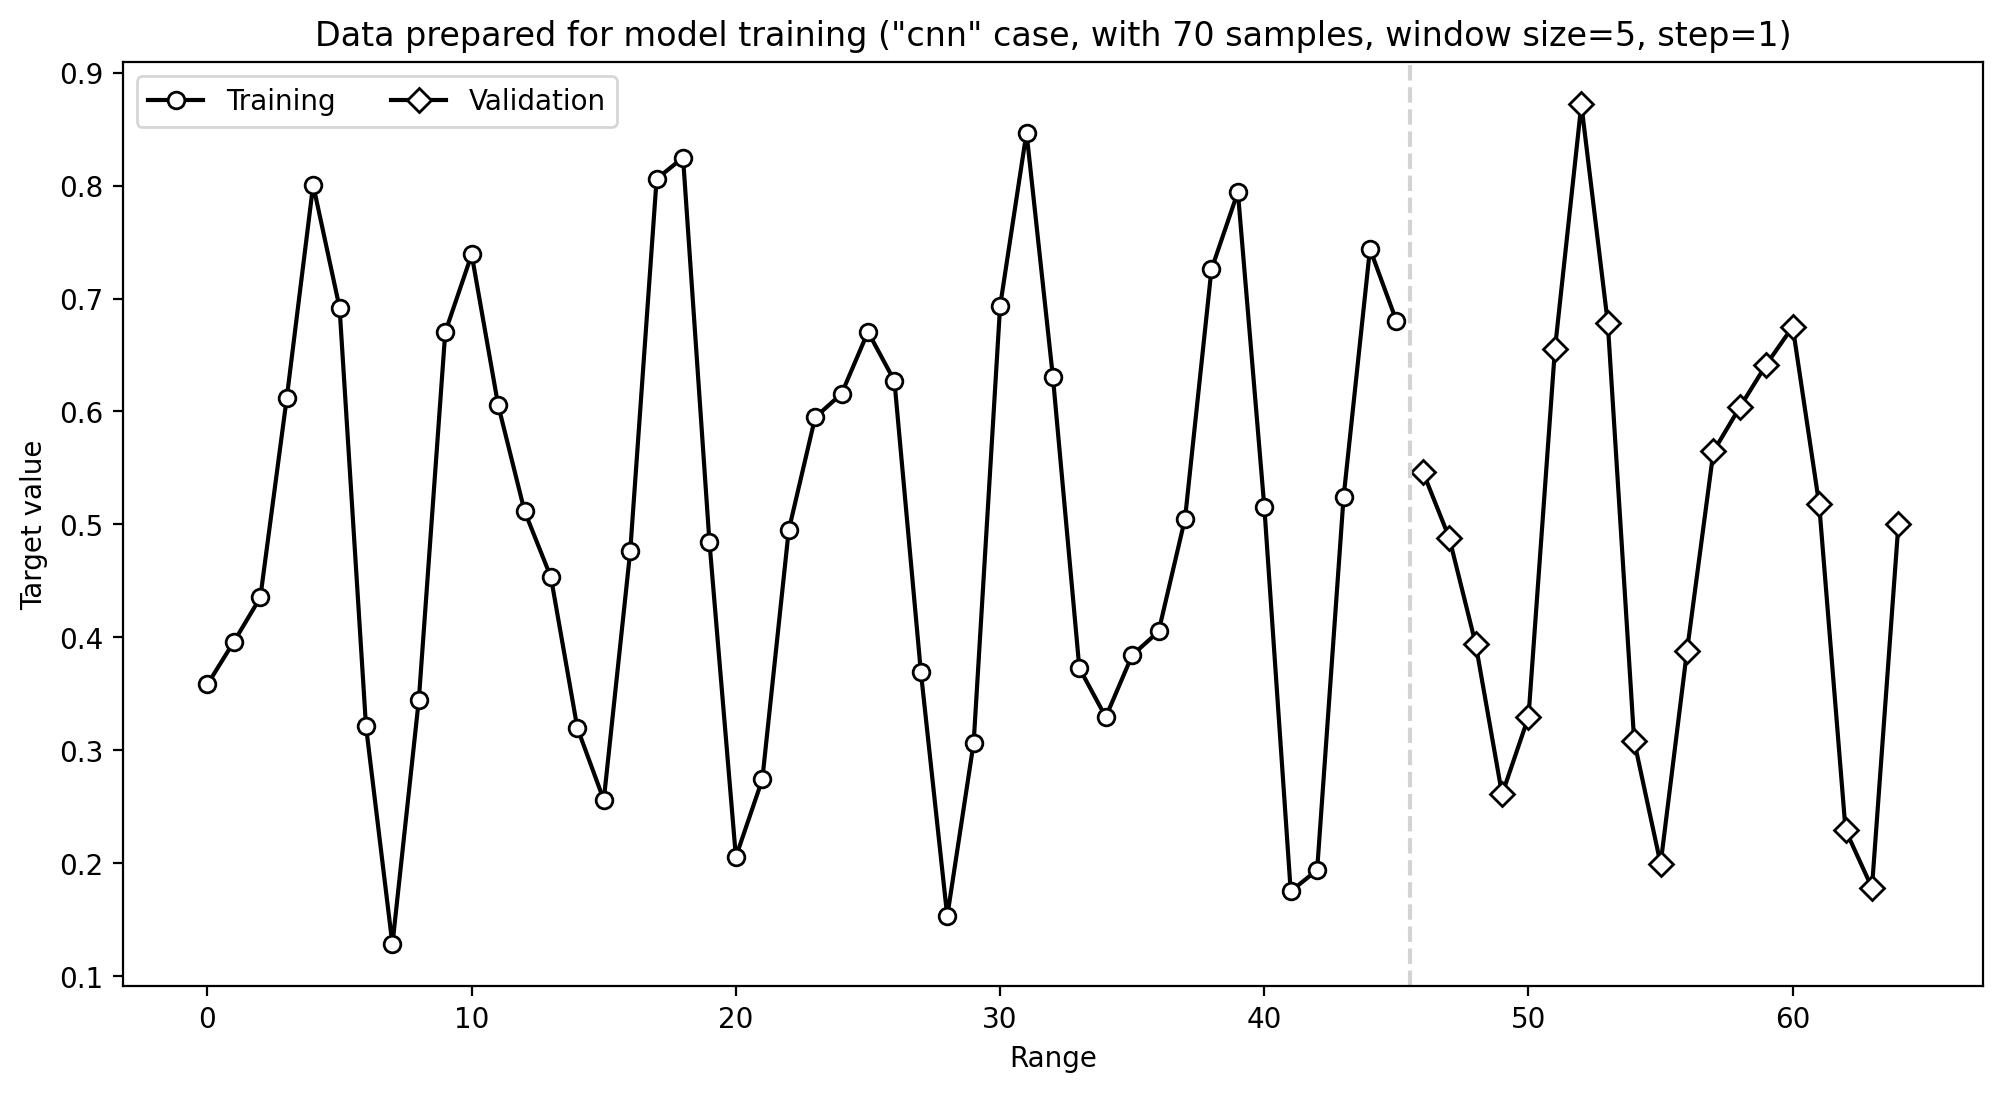

In [9]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['black', 'black'], marker_colors=['white', 'white', 'lightgray', 'lightgray'],
    labels = ['Training', 'Validation'], #ylim=(0.1, 1),
    lines = ['solid', 'solid'], markers = ['o', 'D'], legend_cols=2,
    rcParams=(12, 6), dpi=200, 
    title=f'Data prepared for model training ("{CASE_NAME}" case, '+
          f'with {samples} samples, window size={wind_size}, step={wind_step})')
print()

## Fetch all training parameters and cost history

In [10]:
### Reconstruct training prefix
ANALYSIS_PREF = TRAIN_ID

In [11]:
### Collect all instance numbers
inst_list = []
for sel_inst in range(inst_no):
    
    ### Training info files 
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.pkl'
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.pkl'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.pkl'

    ### Check if any of the files are missing
    if  not if_path_exists(init_fpath) or \
        not if_path_exists(history_fpath) or \
        not if_path_exists(params_fpath):
        print(f'*** ERROR: Incomplete instance: {os.path.basename(os.path.dirname(init_fpath))}')
    else:
        inst_list.append(sel_inst)

print(f'\nFound instances: {inst_list}\n')


Found instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [12]:
### Initialise all instance lists
insts_init_weights = []
insts_objfun_vals = []
insts_params_vect = []

### Collect all valid instance data
for sel_inst in inst_list:
    ### Training info files 
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.pkl'
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.pkl'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.pkl'

    ### Read training data
    objfun_vals = read_pickle_file(history_fpath)
    init_weights = read_pickle_file(init_fpath)
    params_vals = read_pickle_file(params_fpath)
    insts_init_weights.append(init_weights)
    insts_objfun_vals.append(objfun_vals)
    insts_params_vect.append(params_vals)

print(f'\nCollected instances: {inst_list}\n')


Collected instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



## Load all analysis data

In [13]:
print(f'\nLoading model scores for all available instances: ', end='')

inst_no = len(inst_list)

### Init predictions for all instances
insts_train_preds = [[]] * inst_no
insts_test_preds = [[]] * inst_no

### Init scores
insts_train_mae_scores = [[]] * inst_no
insts_train_mse_scores = [[]] * inst_no
insts_train_r2_scores = [[]] * inst_no
insts_test_mae_scores = [[]] * inst_no
insts_test_mse_scores = [[]] * inst_no
insts_test_r2_scores = [[]] * inst_no

for inst_idx in range(inst_no):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Training info files 
    train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.pkl'
    train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.pkl'
    train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.pkl'
    train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.pkl'

    test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.pkl'
    test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.pkl'
    test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.pkl'
    test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.pkl'

    ### Read the scores
    insts_train_preds[inst_idx] = read_pickle_file(train_preds_fpath)
    insts_train_mae_scores[inst_idx] = read_pickle_file(train_mae_scores_fpath)
    insts_train_mse_scores[inst_idx] = read_pickle_file(train_mse_scores_fpath)
    insts_train_r2_scores[inst_idx] = read_pickle_file(train_r2_scores_fpath)

    insts_test_preds[inst_idx] = read_pickle_file(test_preds_fpath)
    insts_test_mae_scores[inst_idx] = read_pickle_file(test_mae_scores_fpath)
    insts_test_mse_scores[inst_idx] = read_pickle_file(test_mse_scores_fpath)
    insts_test_r2_scores[inst_idx] = read_pickle_file(test_r2_scores_fpath)

    print(f'{sel_inst} ', end='')

print('\n')


Loading model scores for all available instances: 0 1 2 3 4 5 6 7 8 9 



## Plot the analysis results

In [14]:
### Set colours and styles to the best instances
def style_scores(scores, min=True, line_colours=None, line_styles=None):

    scores_len = len(scores)
    if line_colours is None:
        line_colours = np.array(['black', 'black', 'black', 'black']+['lightgray']*(scores_len-4))
    if line_styles is None:
        line_styles = np.array(['solid', 'dashed', 'dashdot', 'dotted']+['solid']*(scores_len-4))
    line_colours = np.array(line_colours)
    line_styles = np.array(line_styles)

    # Organise all stats
    scores_list = []
    for i in range(len(scores)):
        scores_arr = np.array(scores[i])
        if min:
            opt_score = np.min(scores_arr)
            opt_pos = np.argmin(scores_arr)
        else:
            opt_score = np.max(scores_arr)
            opt_pos = np.argmax(scores_arr)
        scores_list.append([i, opt_score, opt_pos, len(line_colours)-1, len(line_styles)-1])

    # Reorder scores by optimum value
    scores_tab = np.array(scores_list)   
    sorted_idx = scores_tab[:, 1].argsort()
    sorted_tab = scores_tab[sorted_idx]
    if not min:
        sorted_tab = sorted_tab[::-1]
    
    for i, r in enumerate(sorted_tab):
        sorted_tab[i, 3] = i
        sorted_tab[i, 4] = i
    
    sorted_idx = sorted_tab[:, 0].argsort()
    scores_tab = sorted_tab[sorted_idx]
    scores_cols = line_colours[scores_tab[:, 3].astype(int)]
    scores_styles = line_styles[scores_tab[:, 4].astype(int)]

    return scores_tab, scores_cols, scores_styles

### Plot the training cost (MSE) of all individual instances

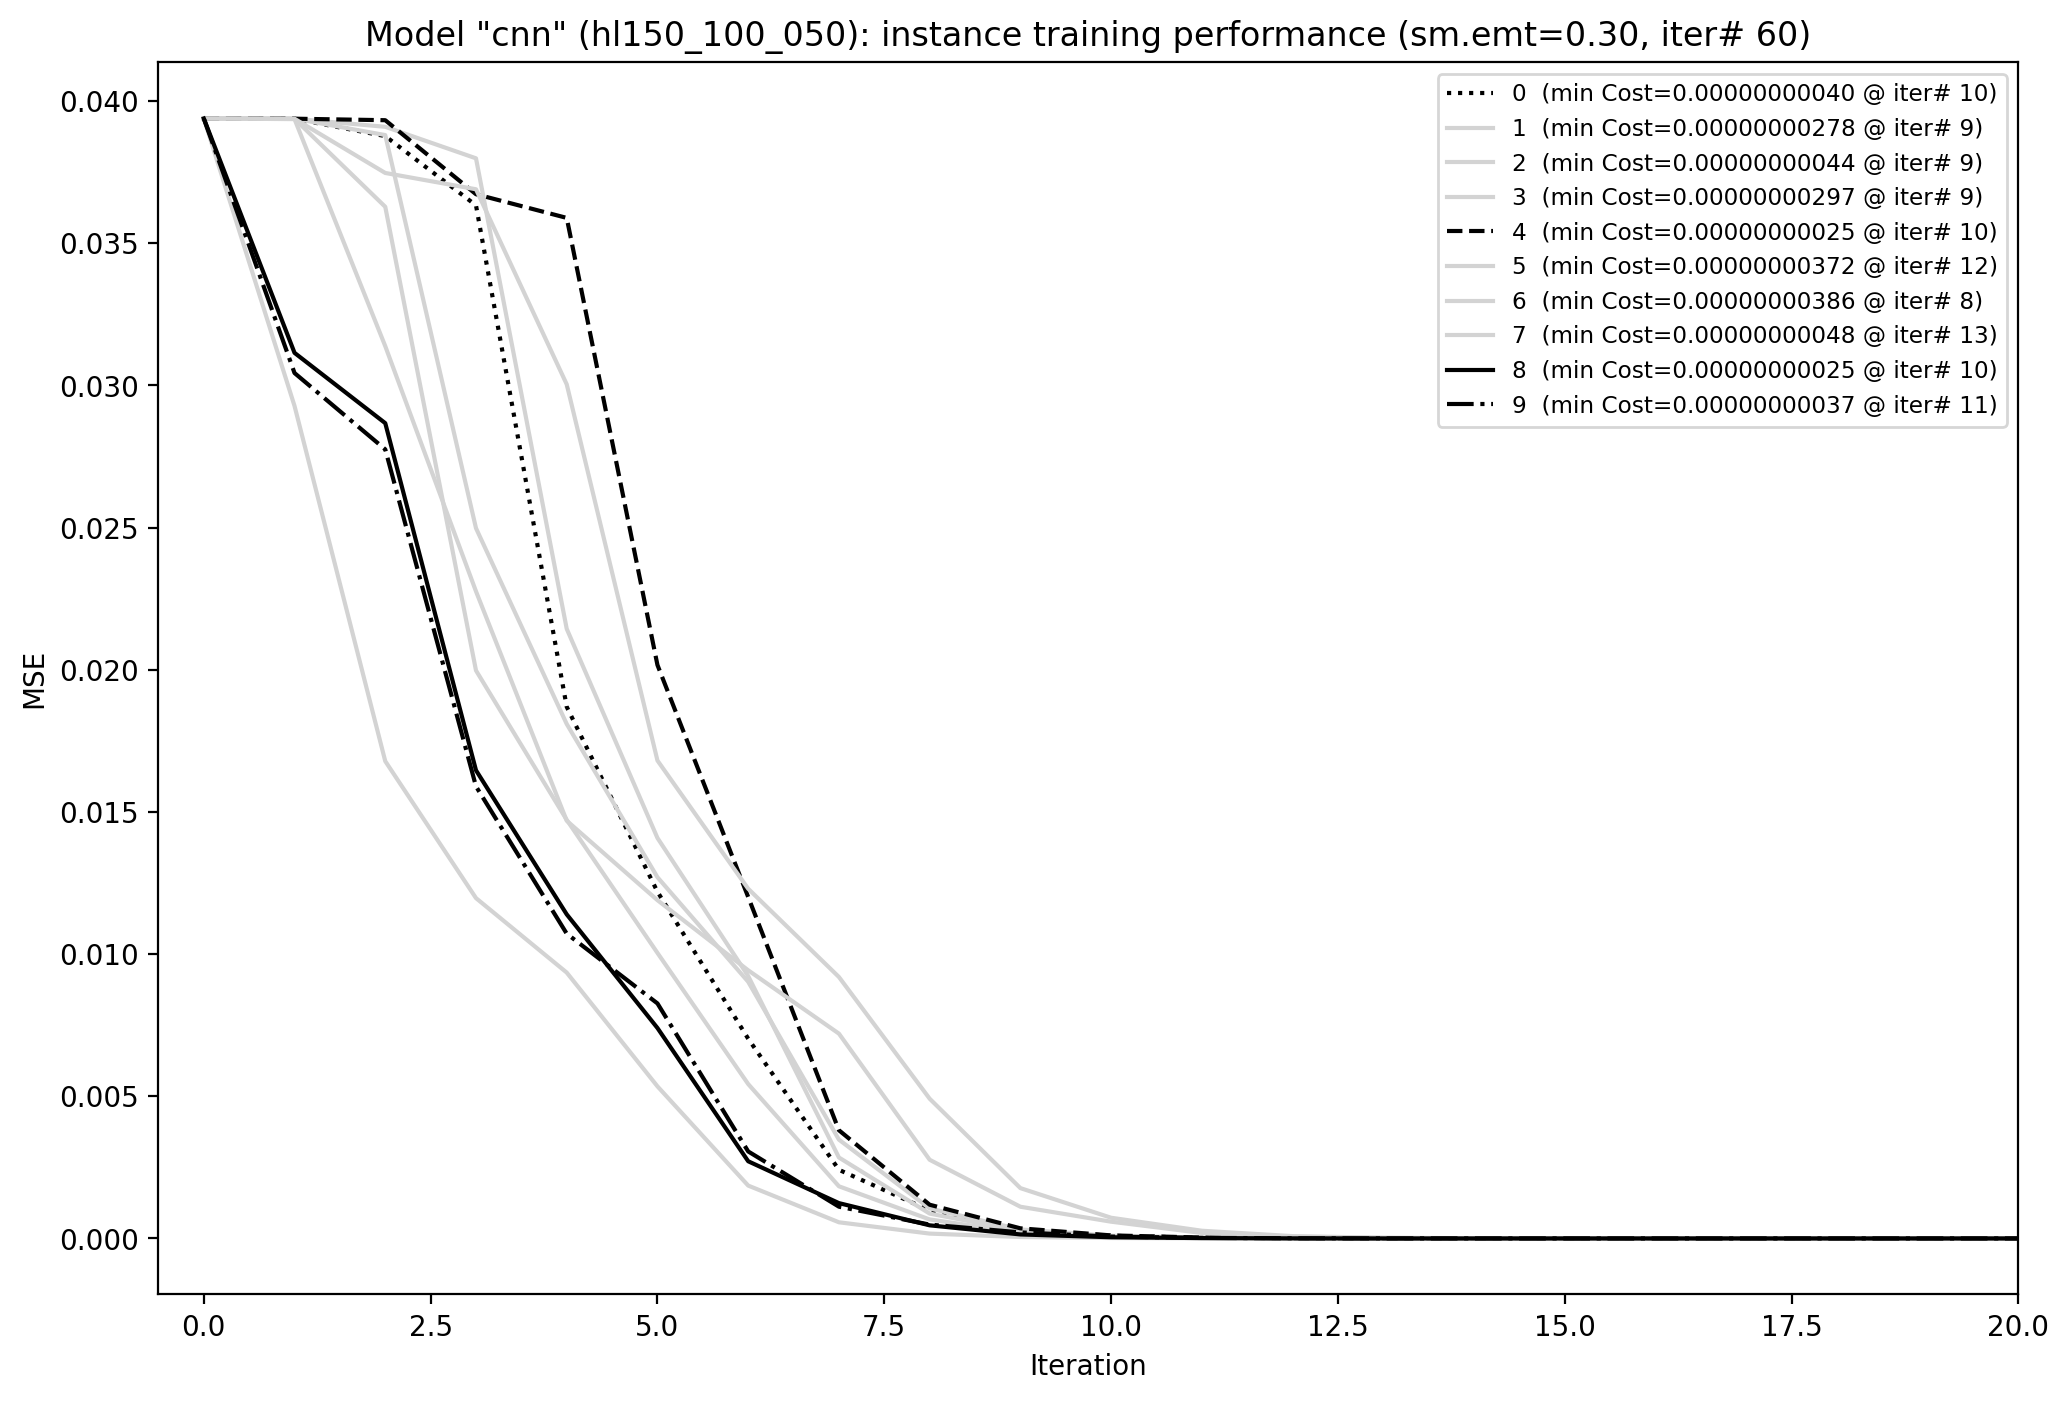

In [15]:
### Plot all trained instances
scores = insts_train_mse_scores
scores_tab, scores_colours, scores_styles = style_scores(scores, min=True)
scores_col_idx = scores_tab[3]
scores_style_idx = scores_tab[4]

model_descr = '_'.join([f'{l:03d}' for l in layers])
log_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_inst_train_perform_lin_bw.eps'
multi_perform_plot(insts_train_mse_scores, log_interv=log_interv, smooth_weight=0.3, 
    rcParams=(12, 8), dpi=200, ylabel=f'MSE', xlim=(-0.5, 20),
    line_cols=scores_colours, line_styles=scores_styles,
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+
          f'instance training performance', opt_format='0.11f',
    labels=inst_list, save_plot=log_plot_path
    )

### Plot the testing cost (MSE) of all individual instances

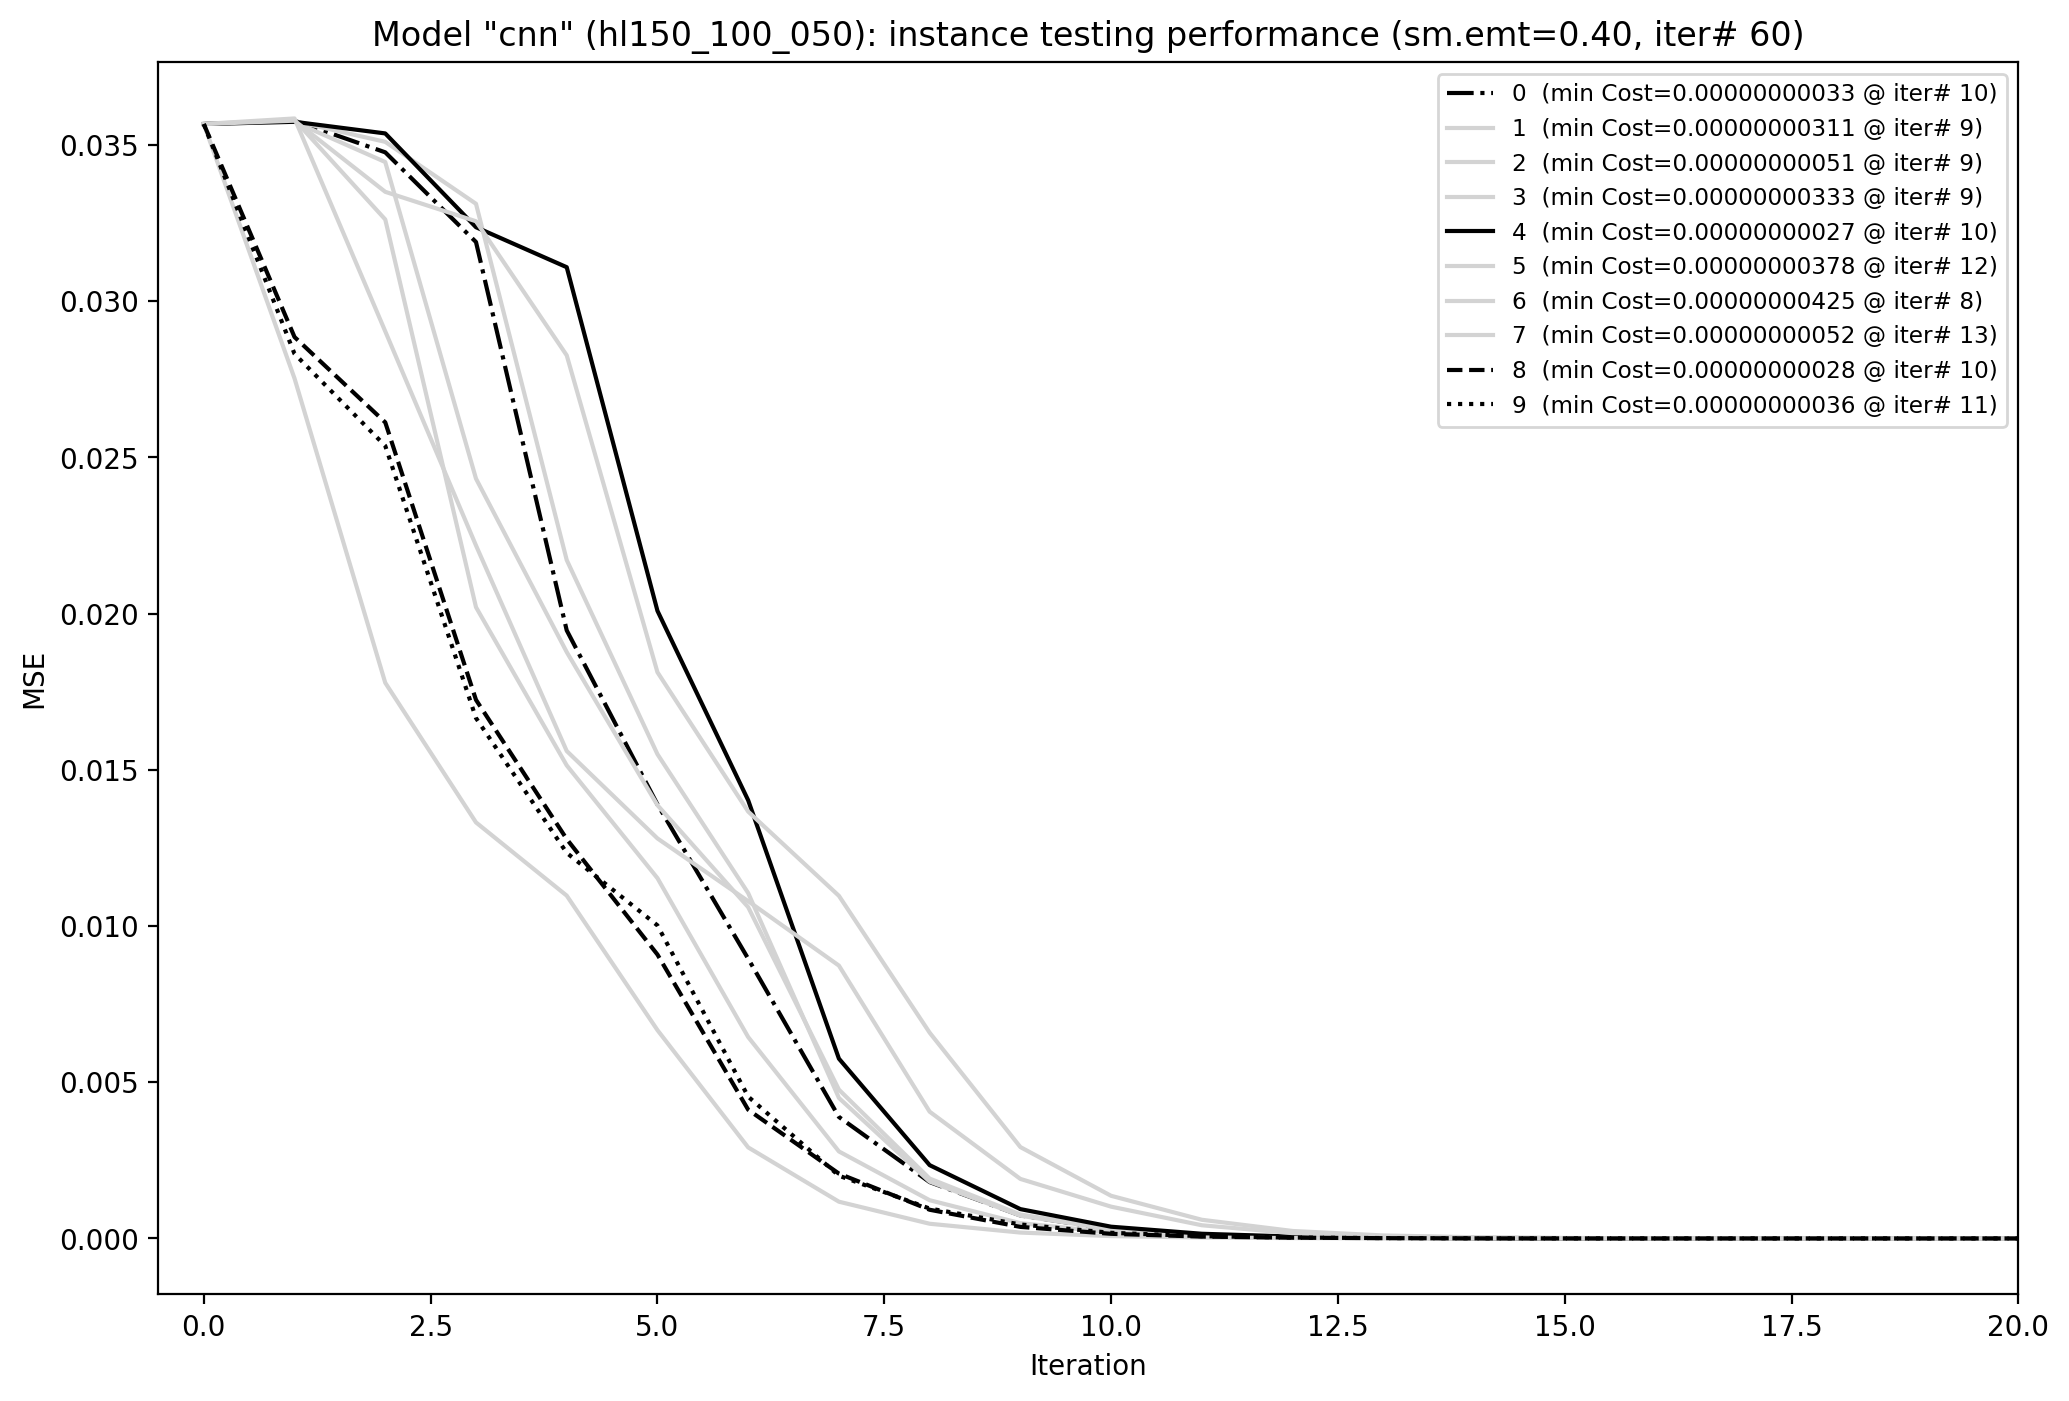

In [16]:
### Plot all tested instances
scores = insts_test_mse_scores
scores_tab, scores_colours, scores_styles = style_scores(scores, min=True)
scores_col_idx = scores_tab[3]
scores_style_idx = scores_tab[4]

model_descr = '_'.join([f'{l:03d}' for l in layers])
log_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_inst_test_perform_lin_bw.eps'
multi_perform_plot(insts_test_mse_scores, log_interv=log_interv, smooth_weight=0.4, 
    rcParams=(12, 8), dpi=200, ylabel=f'MSE',  xlim=(-0.5, 20), # yscale='log',
    line_cols=scores_colours, line_styles=scores_styles,
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+
          f'instance testing performance', opt_format='0.11f', 
    labels=inst_list, save_plot=log_plot_path
    )

### Plot the range and average MSE score of all model instances

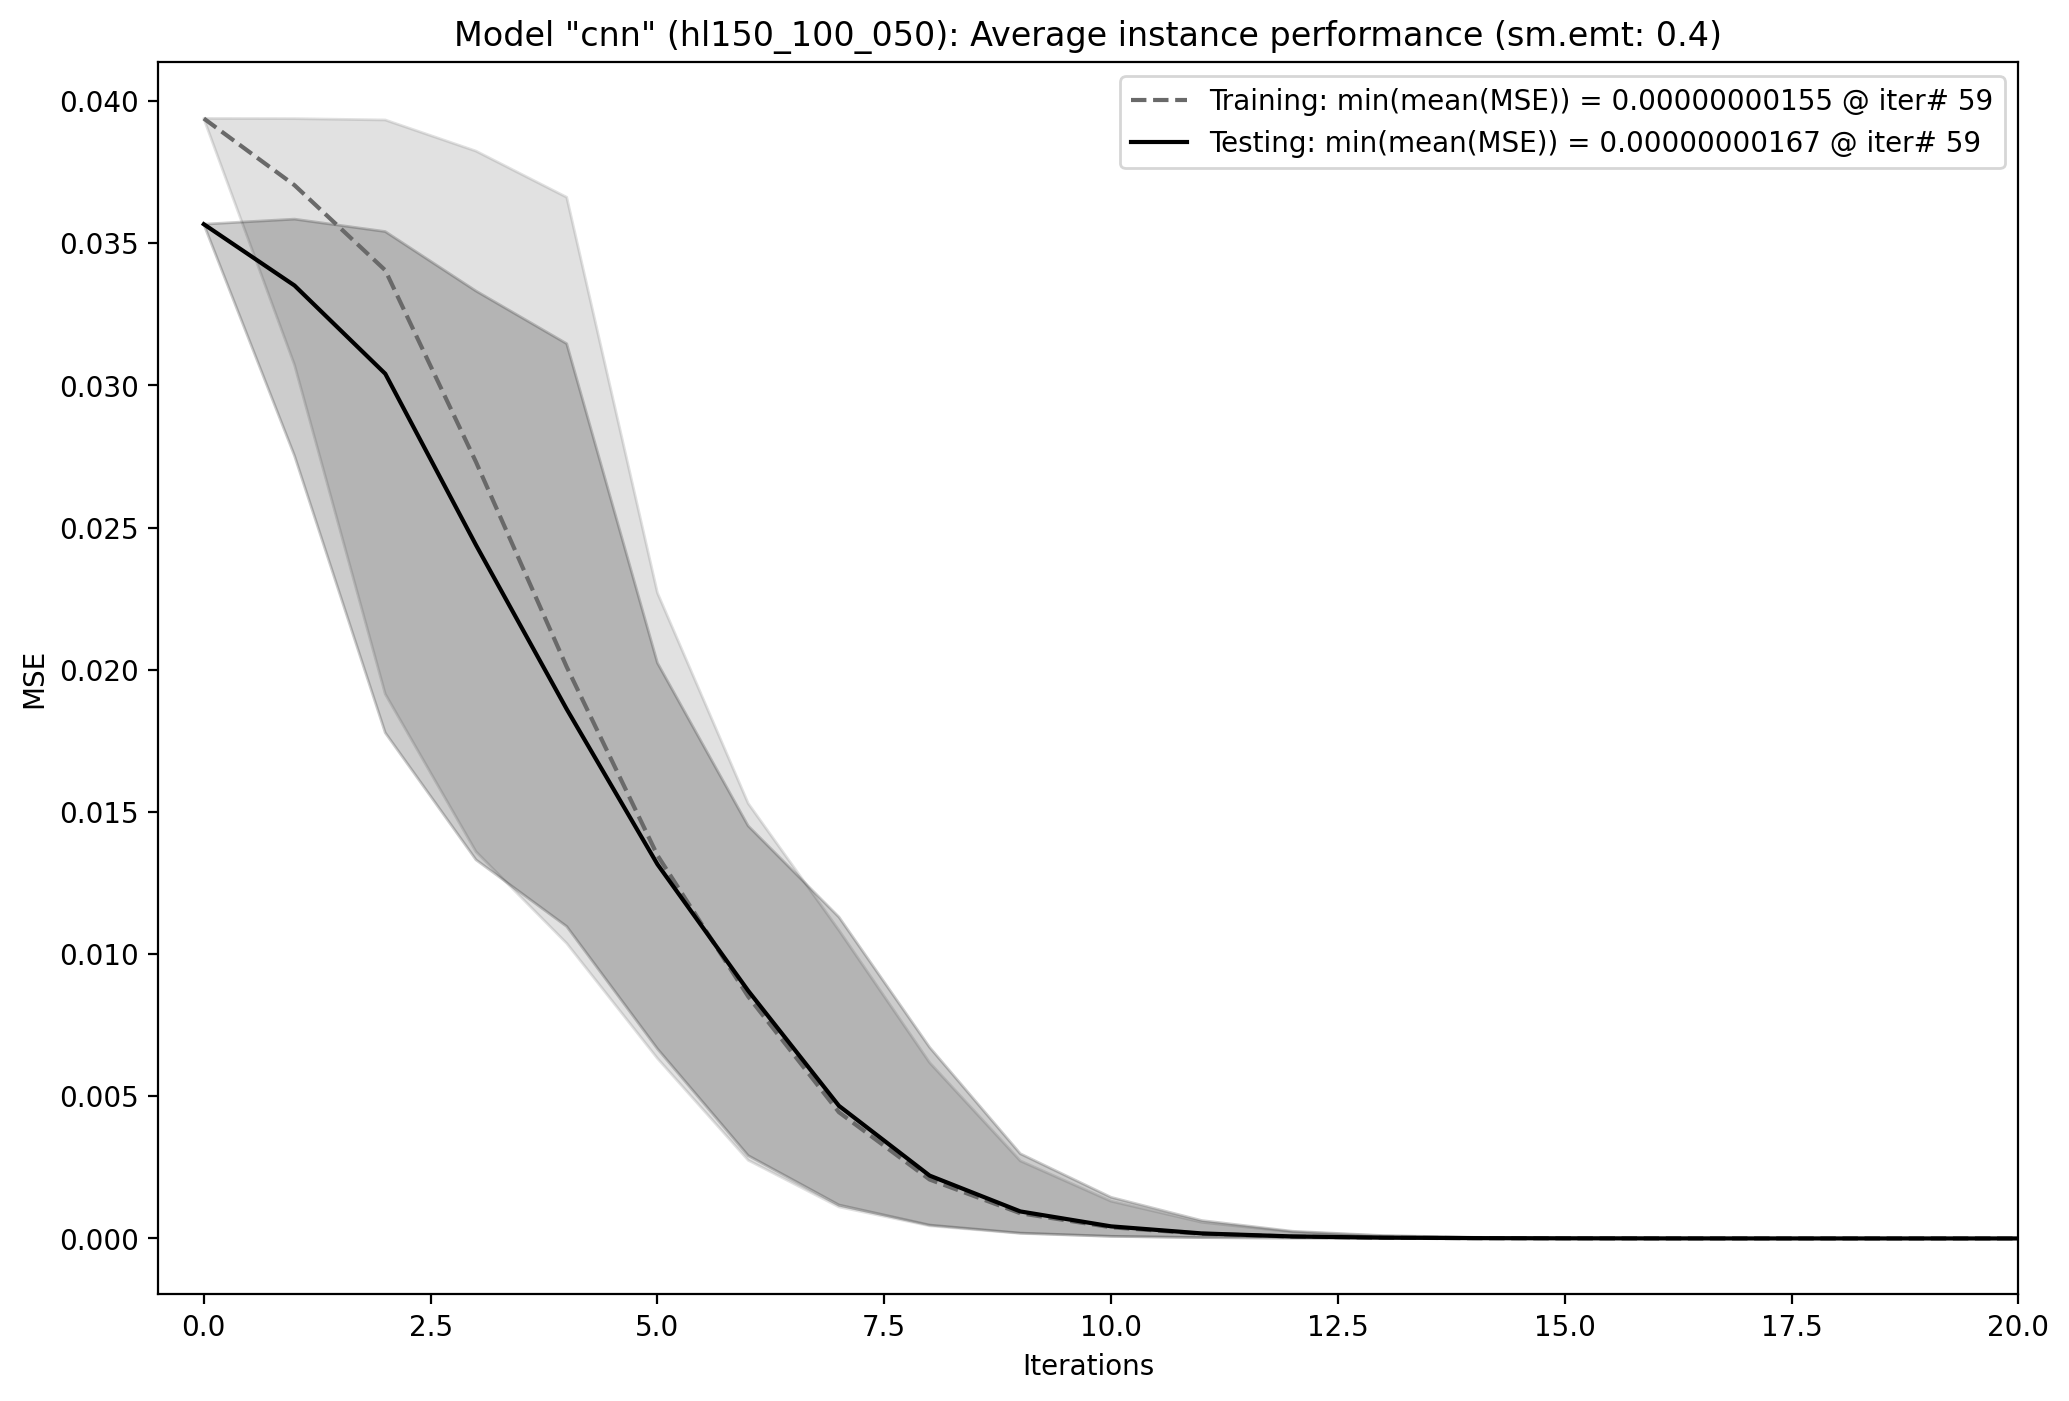

In [17]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
model_descr = '_'.join([f'{l:03d}' for l in layers])
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+ \
    f'hl{model_descr}_inst_perform_range_mse_bw.png'
plot_objfn_range([[np.array(x) for x in insts_train_mse_scores], [np.array(x) for x in insts_test_mse_scores]], 
    rcParams=(12, 8), dpi=200, objfn_list=['Training', 'Testing'], xlim=(-0.5, 20), 
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'MSE', meas_type='mean(MSE)',
    color = ['dimgray', 'black'], linestyles=['dashed', 'solid'], opt_format='0.11f', 
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+
       f'Average instance performance (sm.emt: {smooth_weight})', 
    save_plot=range_plot_path
    )

### Plot the range and average MAE score of all model instances

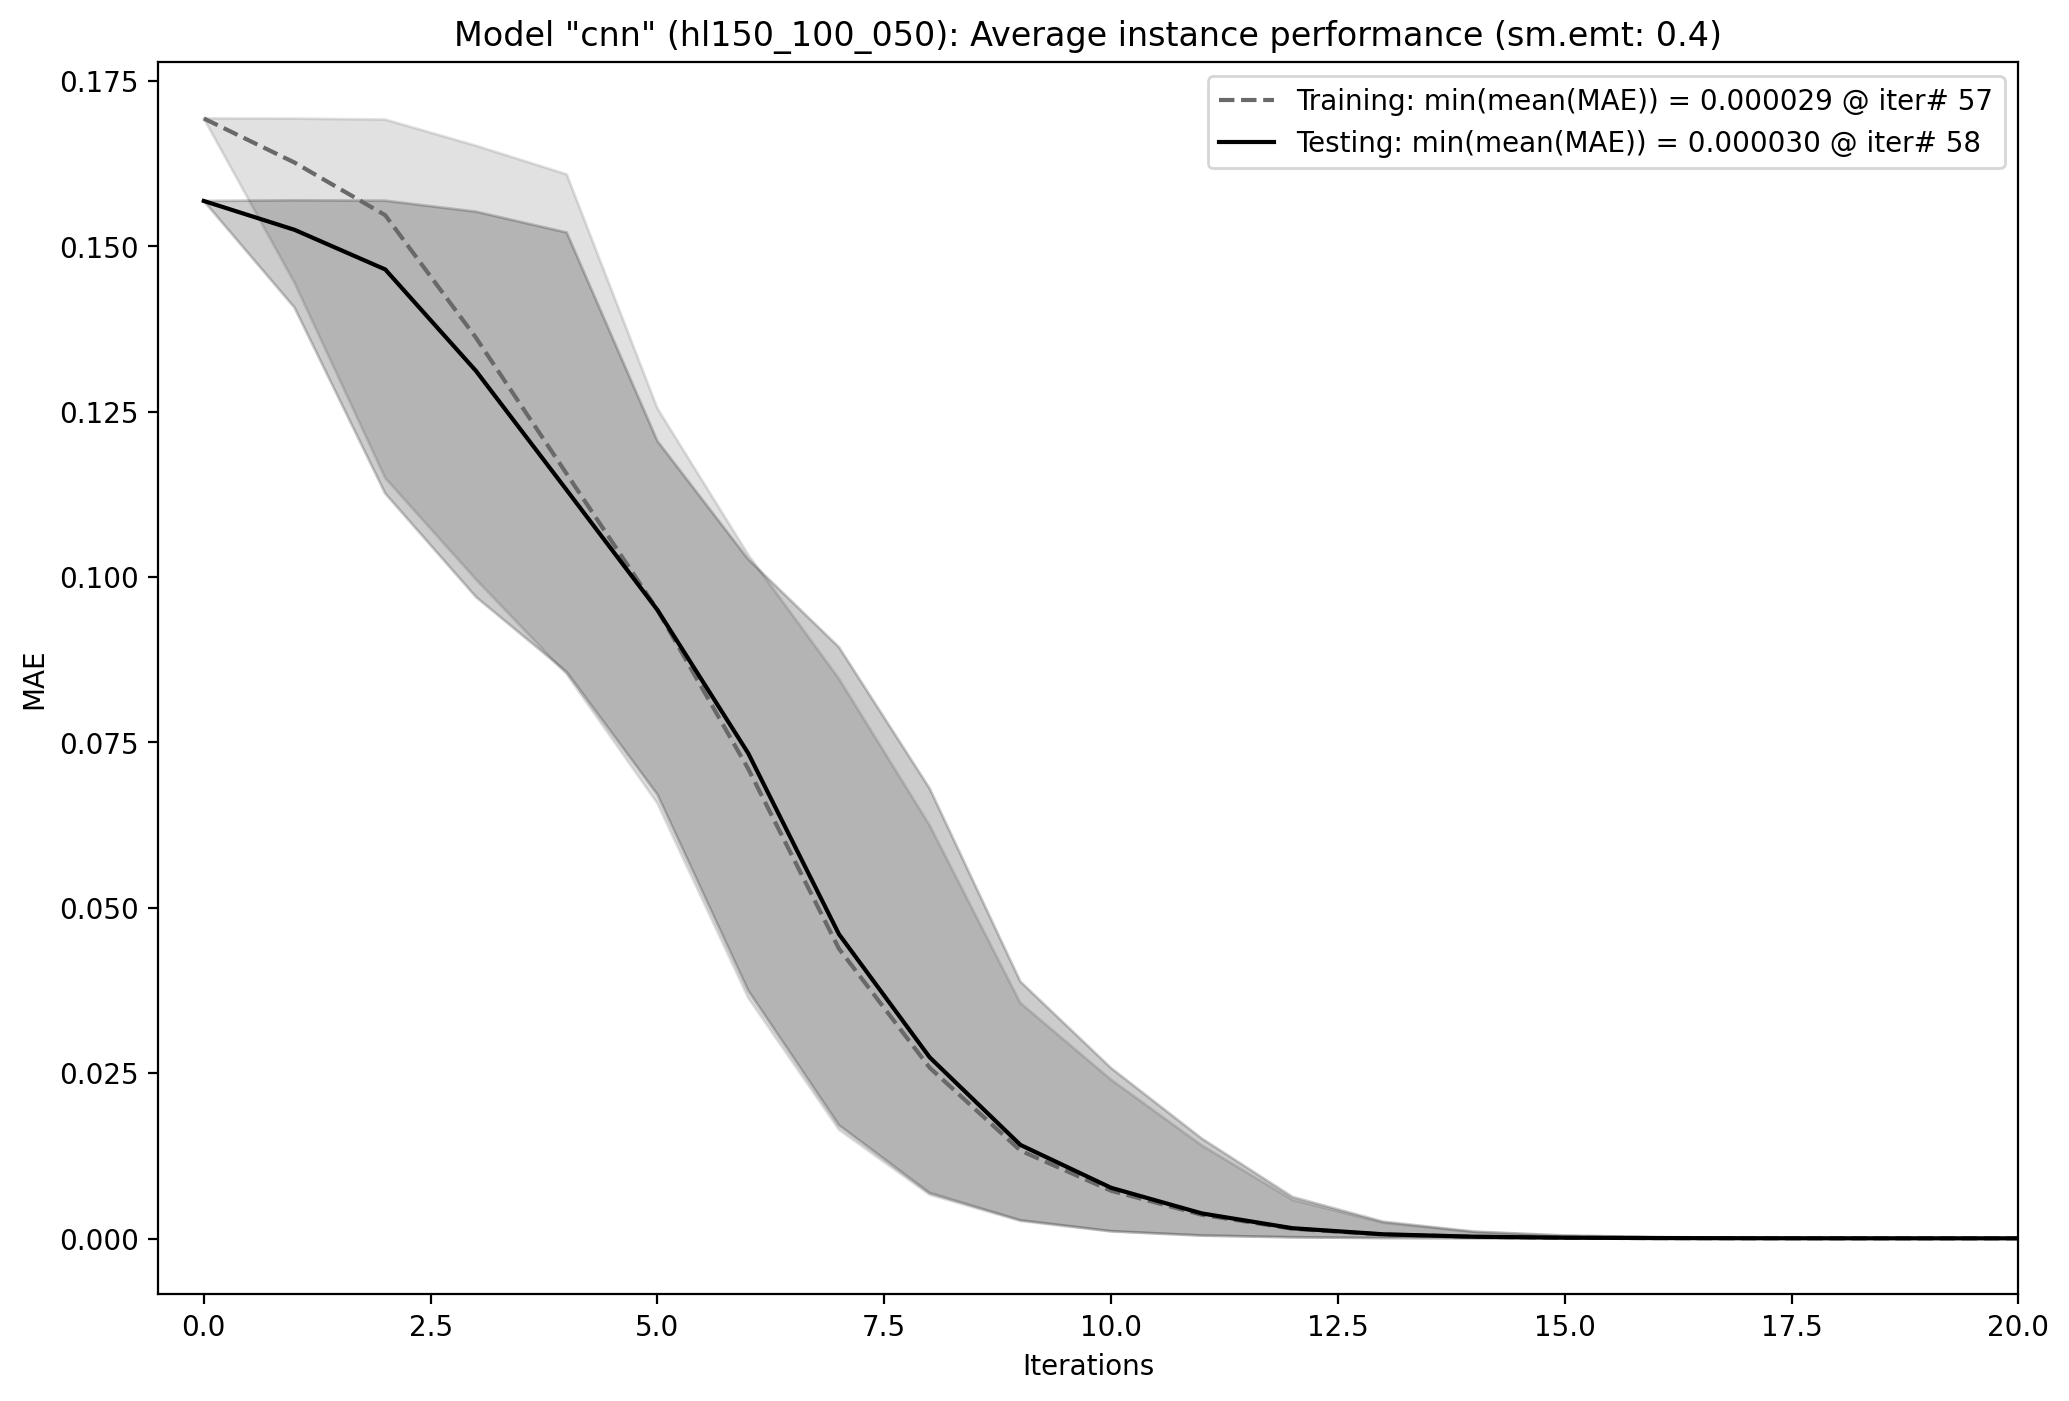

In [18]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
model_descr = '_'.join([f'{l:03d}' for l in layers])
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_inst_perform_range_mae_bw.png'
plot_objfn_range([[np.array(x) for x in insts_train_mae_scores], [np.array(x) for x in insts_test_mae_scores]], 
    rcParams=(12, 8), dpi=200, objfn_list=['Training', 'Testing'], xlim=(-0.5, 20), 
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'MAE', meas_type='mean(MAE)',
    color = ['dimgray', 'black'], linestyles=['dashed', 'solid'], opt_format='0.6f', 
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+ 
       f'Average instance performance (sm.emt: {smooth_weight})', 
    save_plot=range_plot_path
    )

### Plot the range and average R2 score of all model instances

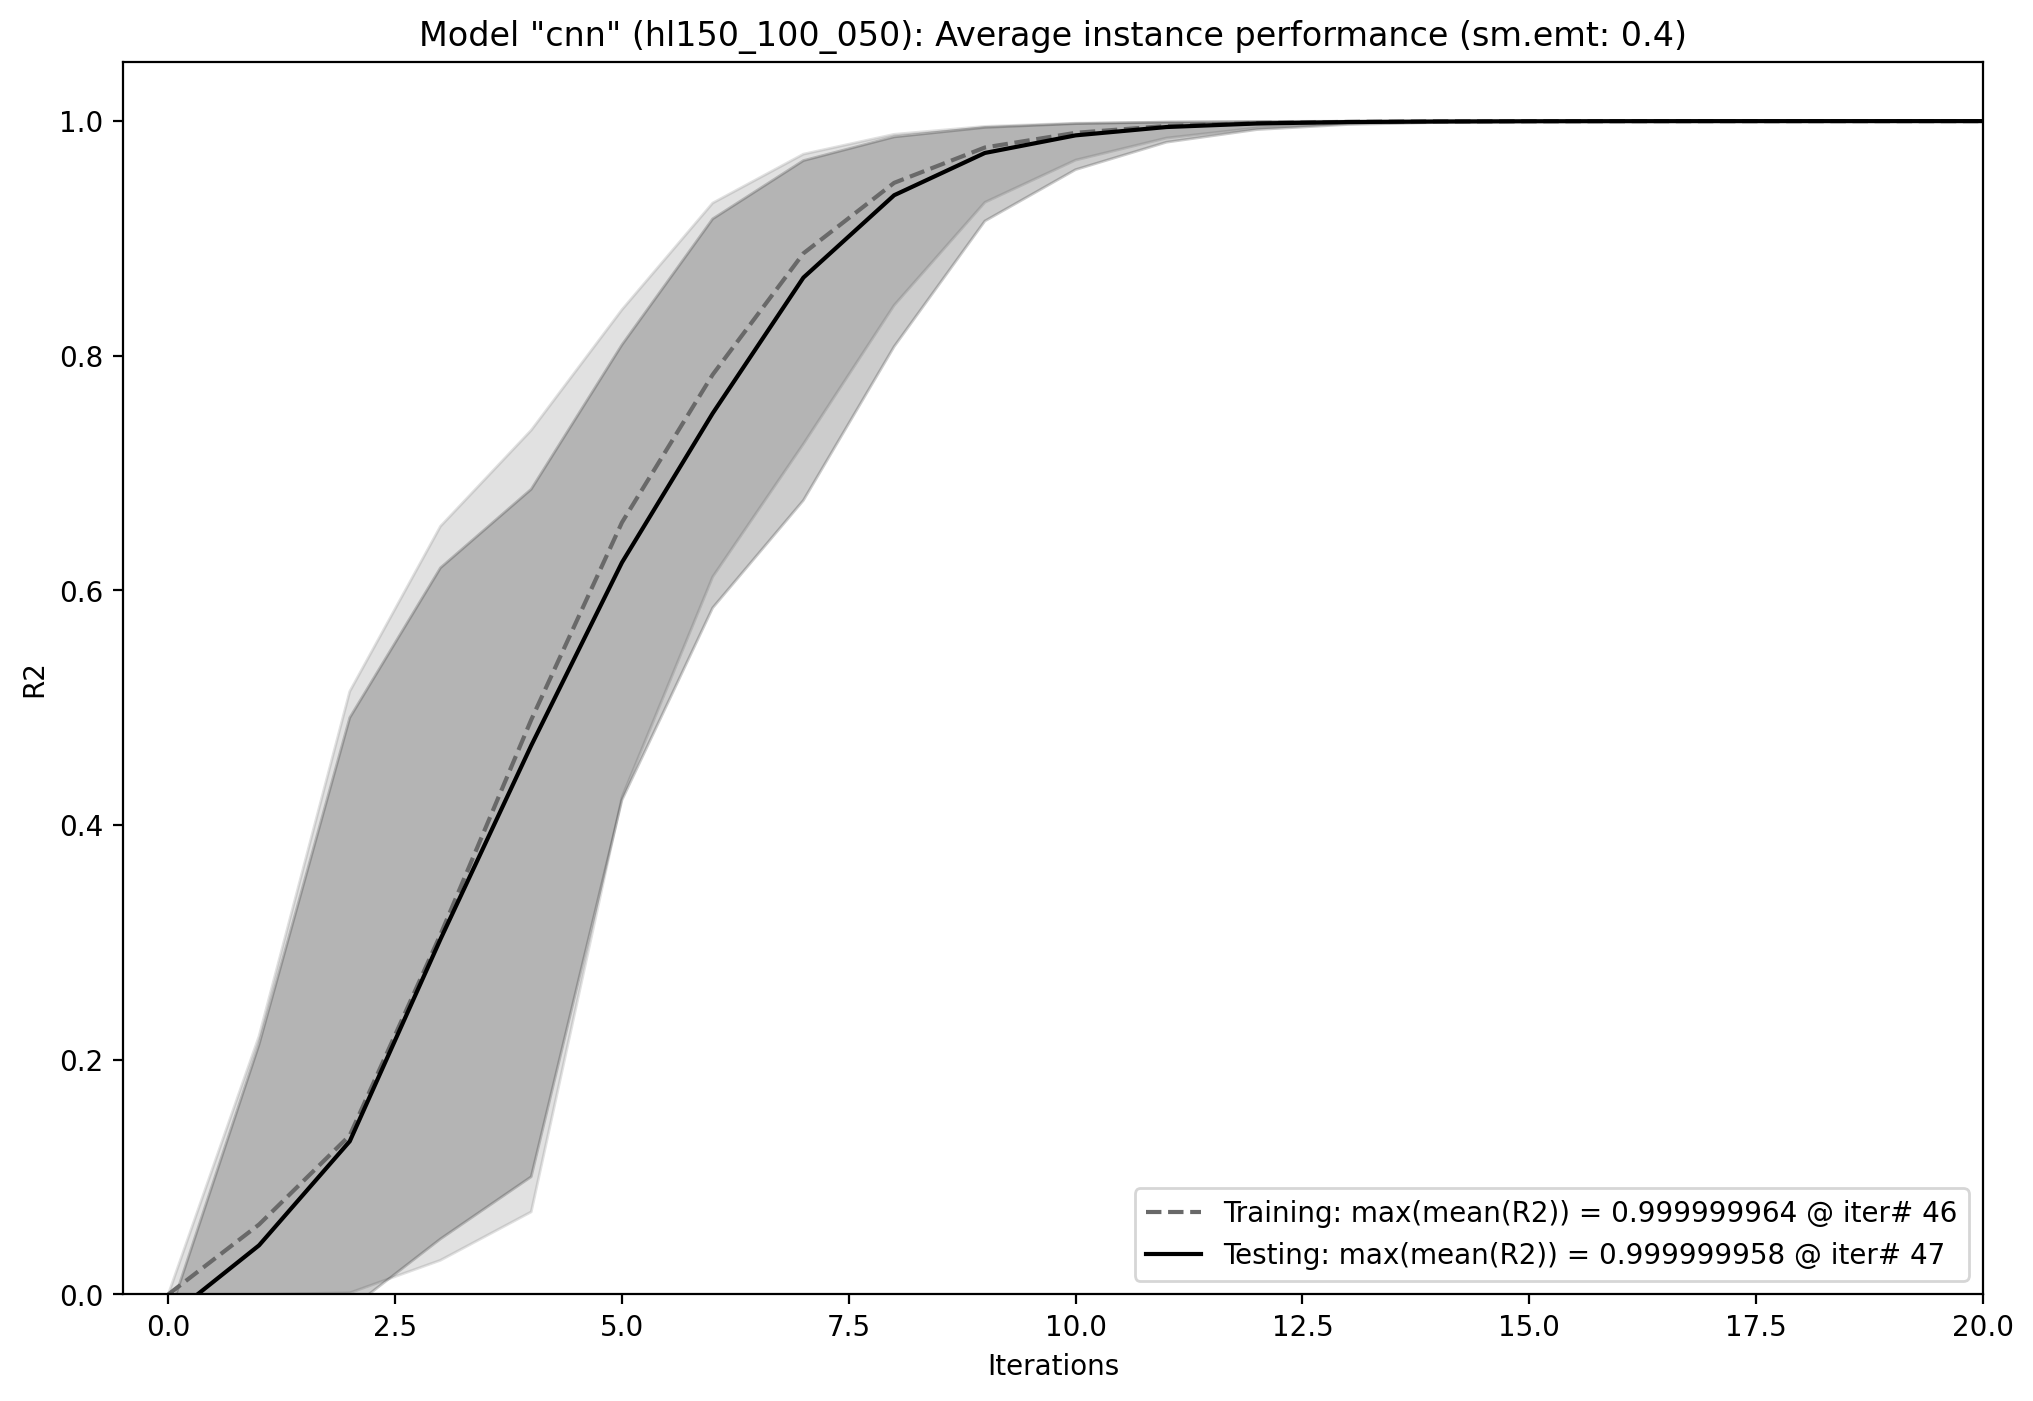

In [19]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
model_descr = '_'.join([f'{l:03d}' for l in layers])
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_inst_perform_range_r2_bw.png'
plot_objfn_range([[np.array(x) for x in insts_train_r2_scores], [np.array(x) for x in insts_test_r2_scores]], 
    rcParams=(12, 8), dpi=200, objfn_list=['Training', 'Testing'], meas_min=False, ylim=(0, 1.05), xlim=(-0.5, 20),
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'R2', meas_type='mean(R2)',
    color = ['dimgray', 'black'], linestyles=['dashed', 'solid'], opt_format='0.9f', 
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+ 
       f'Average instance performance (sm.emt: {smooth_weight})', 
    save_plot=range_plot_path
    )

## Plot the model instance with the best test MSE

In [20]:
### Find the instance with the best (min) minimum MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_min_test_score = np.min(insts_test_min_mse_scores)
sel_inst = int(np.argmin(insts_test_min_mse_scores))
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with the best test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_min_test_score, 5)}\n')


Instance with the best test MSE: 4 @ itr(10) = 0.0



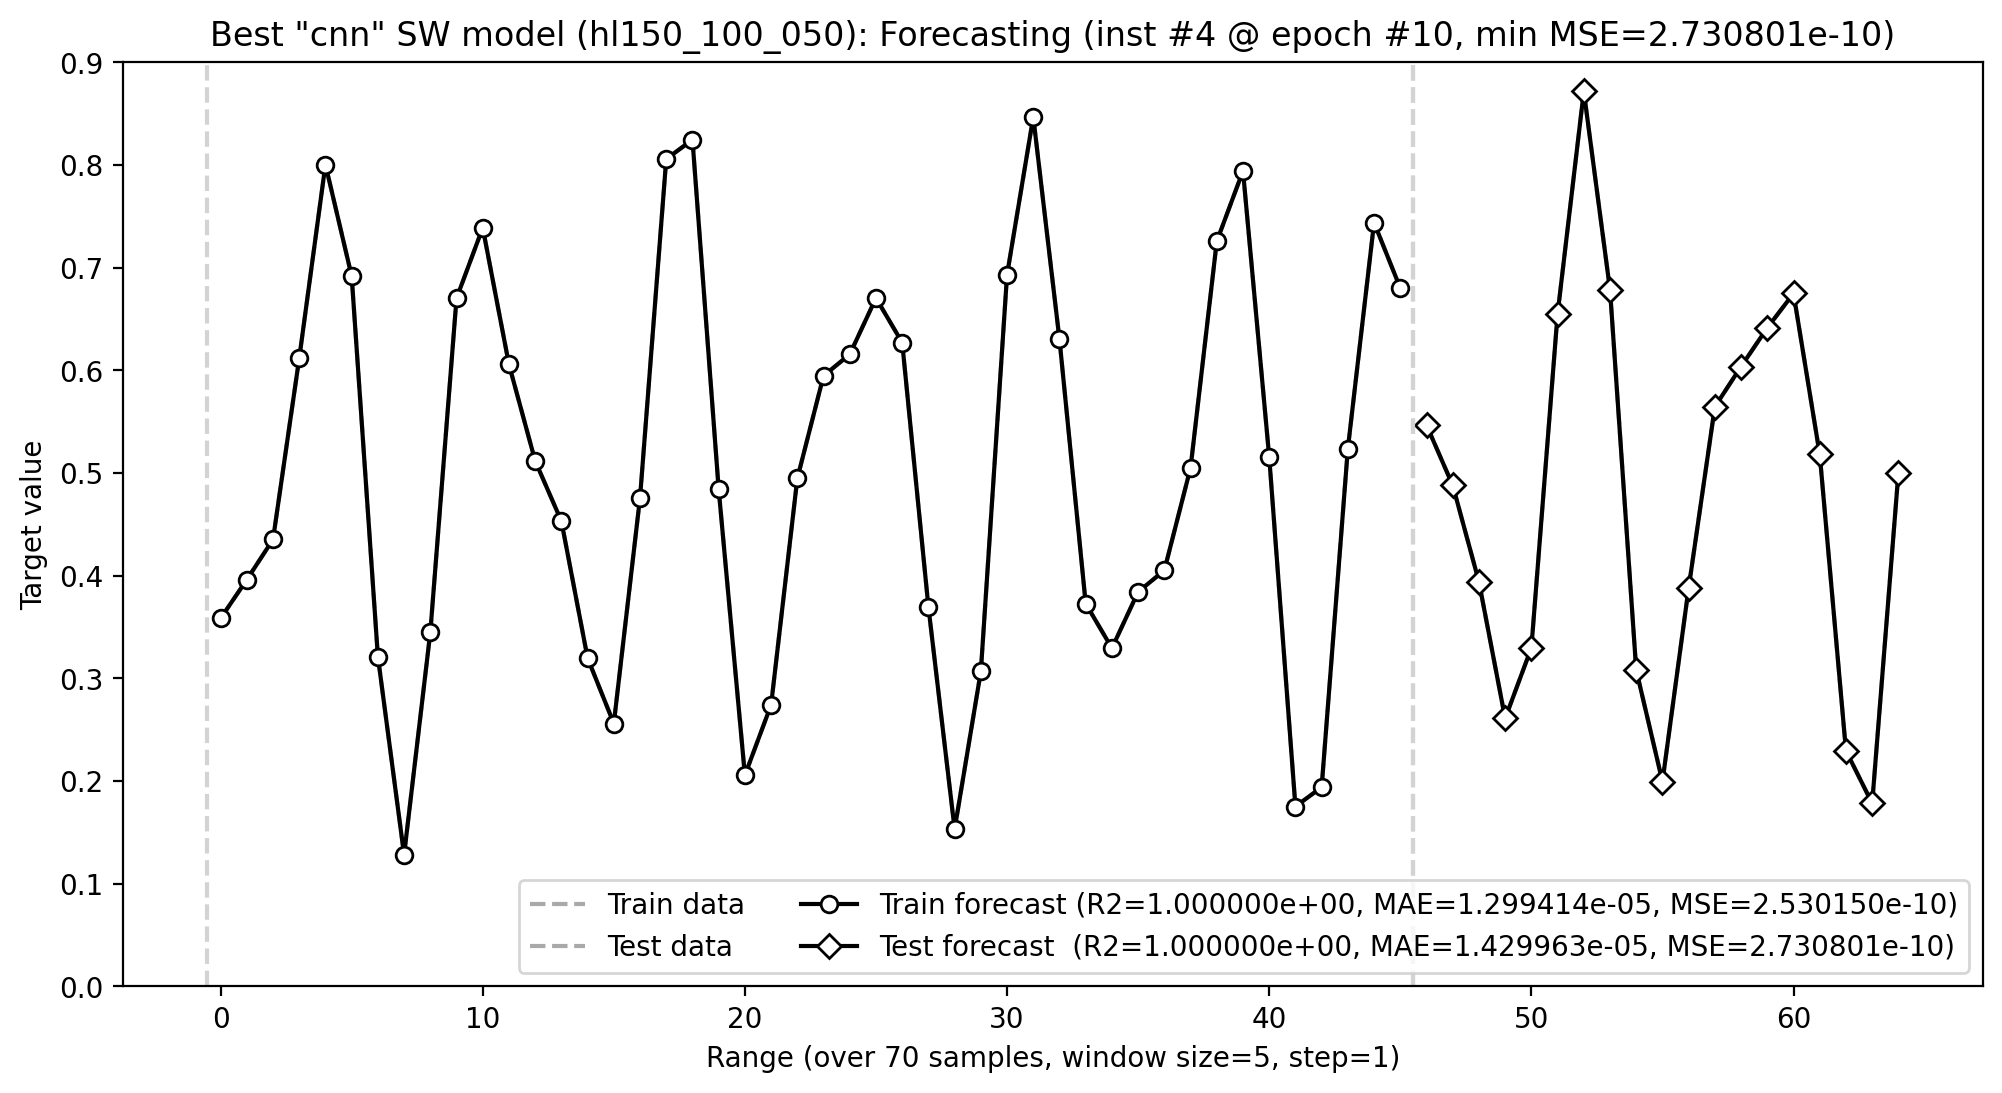

In [21]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

yp_train_hat = insts_train_preds[sel_inst][sel_params_no]
yp_valid_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_train_hat_flat_ts = ts_wind_flatten_avg(yp_train_hat.reshape(y_train_ts.shape), wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_valid_hat_flat_ts = ts_wind_flatten_avg(yp_valid_hat.reshape(y_valid_ts.shape), wind_step)

y_list = [y_train_flat_ts, y_valid_flat_ts, y_train_hat_flat_ts, y_valid_hat_flat_ts]
X_list = [0, len(y_train_flat_ts), 0, len(y_train_flat_ts)]

print()
model_descr = '_'.join([f'{l:03d}' for l in layers])
anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_fitmin_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}_bw.eps'
multi_plot_flat_ts(y_list, X_list=X_list, legend_cols=2, ylim=(0, 0.9),
    colors = ['darkgray', 'darkgray', 'black', 'black'], 
    marker_colors=['white', 'white', 'white', 'white'],
    lines = ['dashed', 'dashed', 'solid', 'solid'], 
    markers = ['none', 'none', 'o', 'D'],
    labels=['Train data', 'Test data', 
            f'Train forecast (R2={train_r2:1e}, MAE={train_mae:5e}, MSE={train_mse:5e})', 
            f'Test forecast  (R2={test_r2:1e}, MAE={test_mae:5e}, MSE={test_mse:5e})'],
    rcParams=(12, 6), dpi=200, 
    xlabel=f'Range (over {samples} samples, window size={wind_size}, step={wind_step})',
    title=f'Best "{CASE_NAME}" SW model (hl{model_descr}): '+
          f'Forecasting (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={sel_min_test_score:5e})',
    save_plot=anlz_fit_path
)
print()

## Plot the model instance with the median minimum test MSE

In [22]:
### Find the median and its location in a list
def arg_median(lst):
    sorted_lst = sorted(lst)
    n = len(sorted_lst)
    if n % 2 == 1: # odd number of elements, the median is the middle element
        median_value = sorted_lst[n // 2]
    else: # even number of elements, the median is the average of the two middle elements
        median_value = sorted_lst[n // 2 - 1]    
    median_index = lst.index(median_value)    
    return median_index, median_value

In [23]:
### Find the instance with the median min MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_inst, sel_median_test_score = arg_median(insts_test_min_mse_scores)
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with median test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_median_test_score, 5)}\n')


Instance with median test MSE: 2 @ itr(9) = 0.0



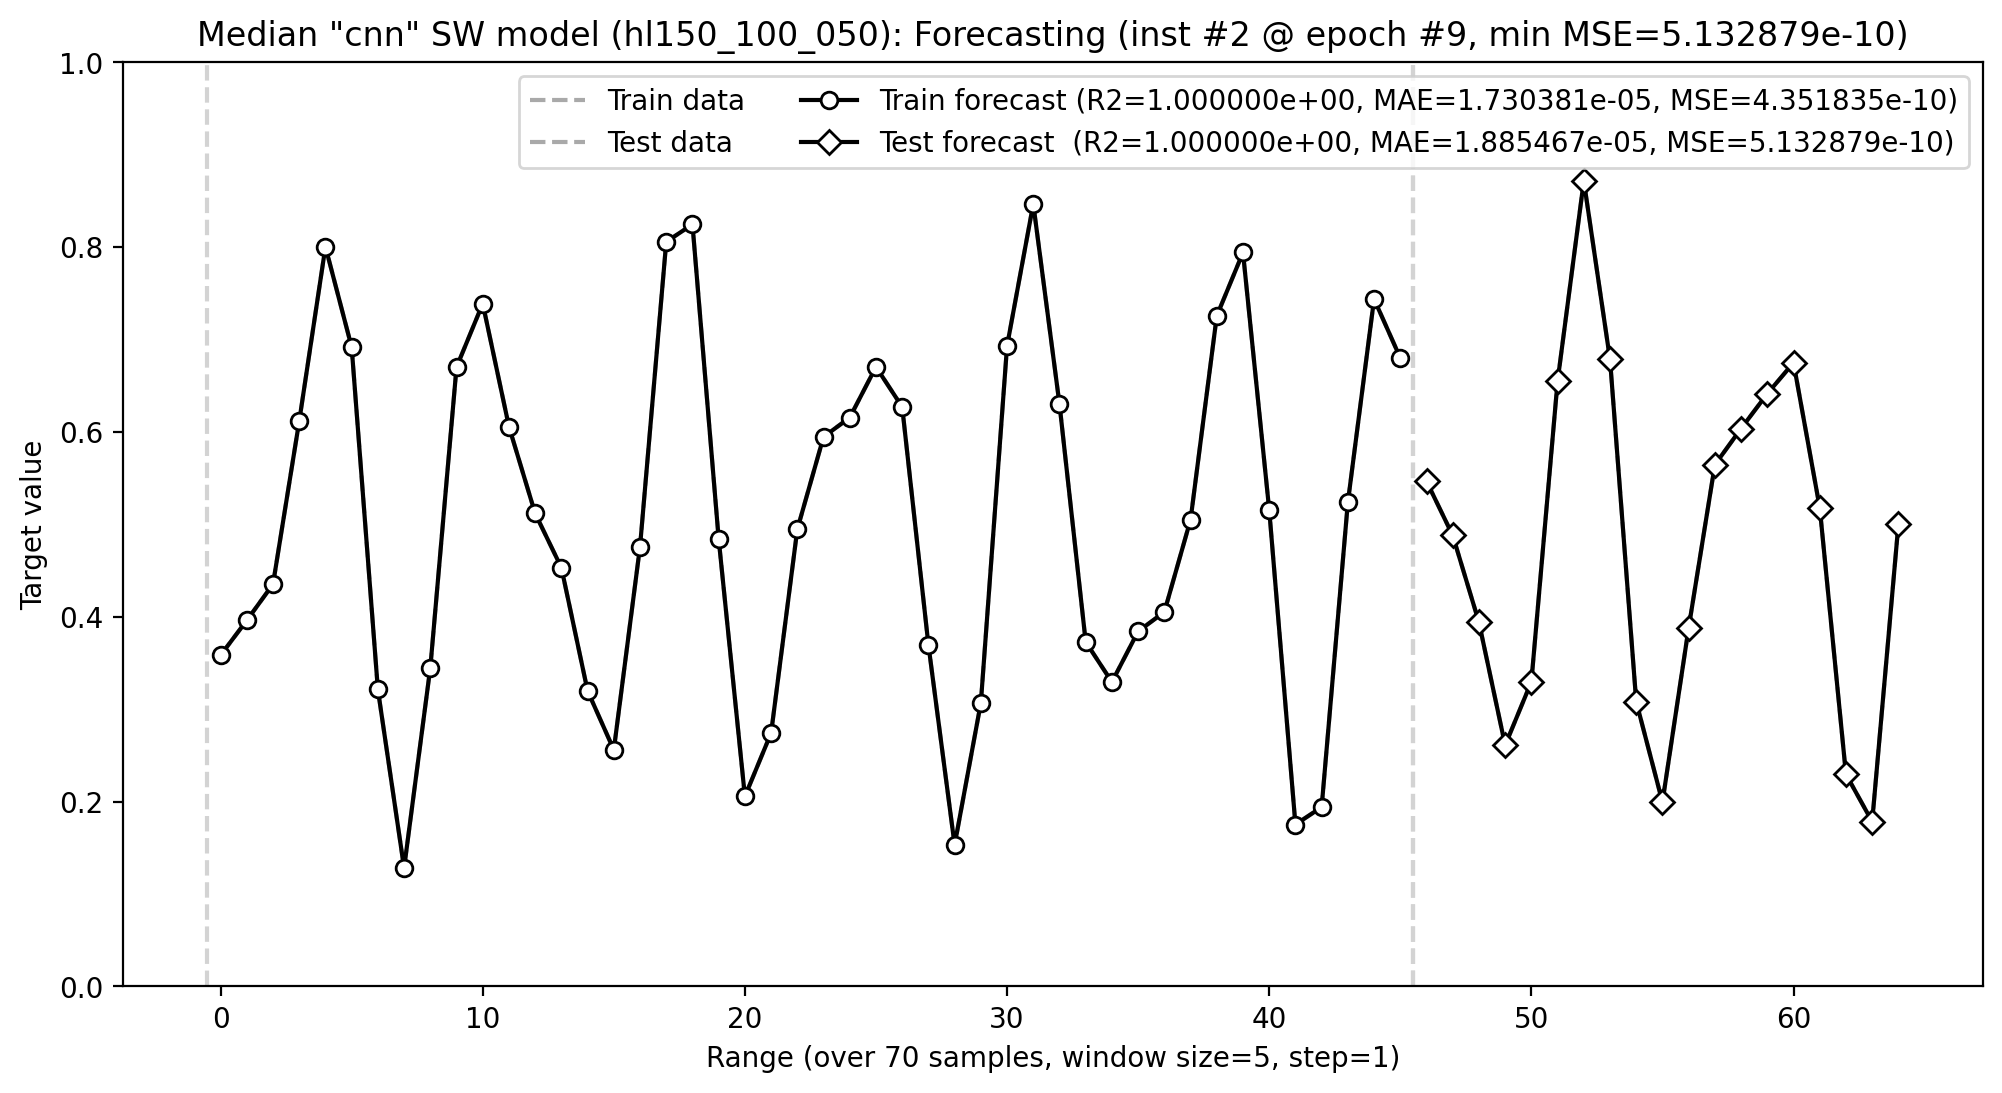

In [24]:
### Plot trainig and validation/test data partitions

yp_train_hat = insts_train_preds[sel_inst][sel_params_no]
yp_valid_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_train_hat_flat_ts = ts_wind_flatten_avg(yp_train_hat.reshape(y_train_ts.shape), wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_valid_hat_flat_ts = ts_wind_flatten_avg(yp_valid_hat.reshape(y_valid_ts.shape), wind_step)

y_list = [y_train_flat_ts, y_valid_flat_ts, y_train_hat_flat_ts, y_valid_hat_flat_ts]
X_list = [0, len(y_train_flat_ts), 0, len(y_train_flat_ts)]

model_descr = '_'.join([f'{l:03d}' for l in layers])
anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_fitmed_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}_bw.eps'
multi_plot_flat_ts(y_list, X_list=X_list, legend_cols=2, ylim=(0, 1),
    colors = ['darkgray', 'darkgray', 'black', 'black'], 
    marker_colors=['white', 'white', 'white', 'white'],
    lines = ['dashed', 'dashed', 'solid', 'solid'], 
    markers = ['none', 'none', 'o', 'D'],
    labels=['Train data', 'Test data', 
            f'Train forecast (R2={train_r2:1e}, MAE={train_mae:5e}, MSE={train_mse:5e})', 
            f'Test forecast  (R2={test_r2:1e}, MAE={test_mae:5e}, MSE={test_mse:5e})'],
    rcParams=(12, 6), dpi=200, 
    xlabel=f'Range (over {samples} samples, window size={wind_size}, step={wind_step})',
    title=f'Median "{CASE_NAME}" SW model (hl{model_descr}): '+
          f'Forecasting (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={sel_median_test_score:5e})',
    save_plot=anlz_fit_path
)

## Plot the model instance with the worst minimum test MSE

In [25]:
### Find the instance with the worst (max) minimum MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_max_test_score = np.max(insts_test_min_mse_scores)
sel_inst = int(np.argmax(insts_test_min_mse_scores))
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with the worst test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_max_test_score, 5)}\n')


Instance with the worst test MSE: 6 @ itr(8) = 0.0



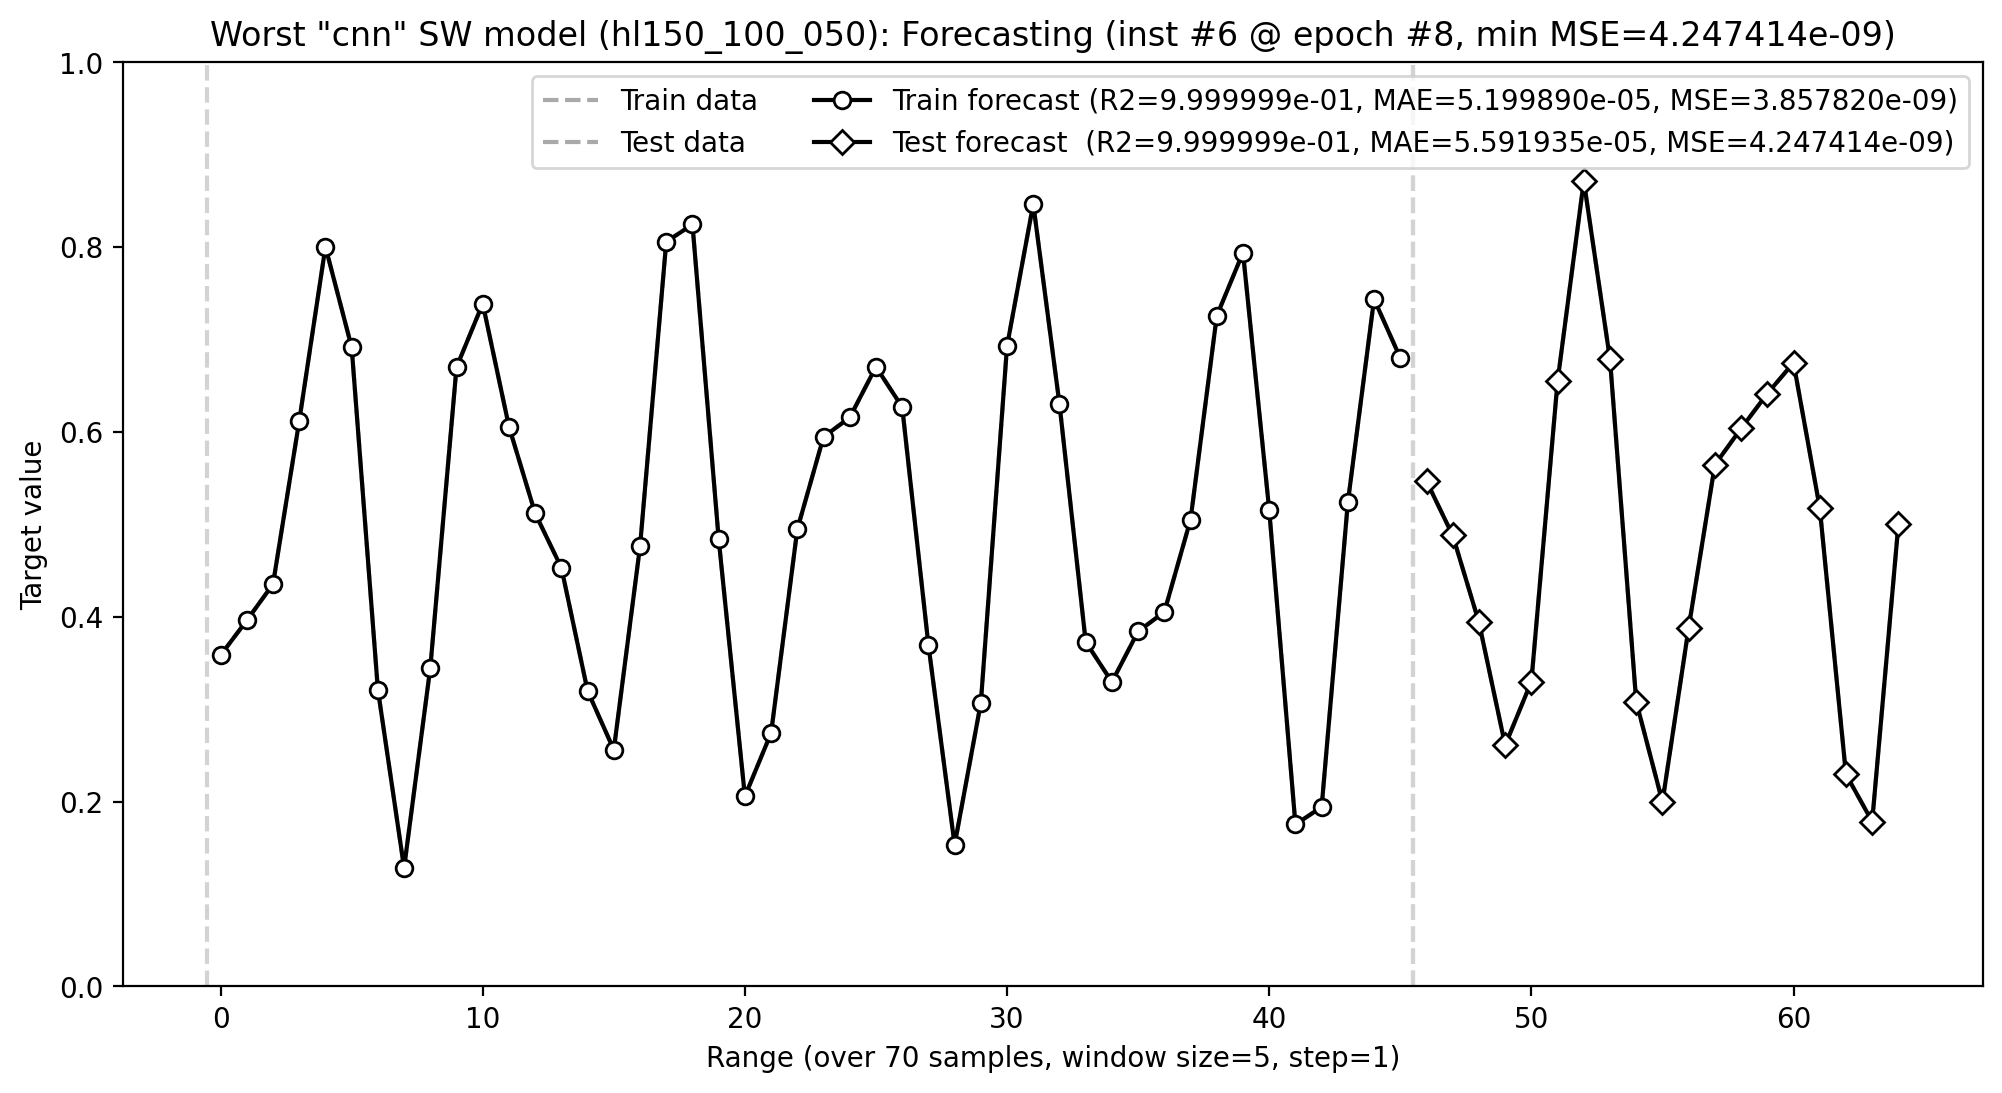

In [26]:
### Plot trainig and validation/test data partitions

yp_train_hat = insts_train_preds[sel_inst][sel_params_no]
yp_valid_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_train_hat_flat_ts = ts_wind_flatten_avg(yp_train_hat.reshape(y_train_ts.shape), wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_valid_hat_flat_ts = ts_wind_flatten_avg(yp_valid_hat.reshape(y_valid_ts.shape), wind_step)

y_list = [y_train_flat_ts, y_valid_flat_ts, y_train_hat_flat_ts, y_valid_hat_flat_ts]
X_list = [0, len(y_train_flat_ts), 0, len(y_train_flat_ts)]

model_descr = '_'.join([f'{l:03d}' for l in layers])
anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_fitmax_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}_bw.eps'
multi_plot_flat_ts(y_list, X_list=X_list, legend_cols=2, ylim=(0, 1),
    colors = ['darkgray', 'darkgray', 'black', 'black'], 
    marker_colors=['white', 'white', 'white', 'white'],
    lines = ['dashed', 'dashed', 'solid', 'solid'], 
    markers = ['none', 'none', 'o', 'D'],
    labels=['Train data', 'Test data', 
            f'Train forecast (R2={train_r2:1e}, MAE={train_mae:5e}, MSE={train_mse:5e})', 
            f'Test forecast  (R2={test_r2:1e}, MAE={test_mae:5e}, MSE={test_mse:5e})'],
    rcParams=(12, 6), dpi=200, 
    xlabel=f'Range (over {samples} samples, window size={wind_size}, step={wind_step})',
    title=f'Worst "{CASE_NAME}" SW model (hl{model_descr}): '+
          f'Forecasting (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={sel_max_test_score:5e})',
    save_plot=anlz_fit_path
)

## System

In [27]:
import os
import sys
print(f"\nOperating environment:\n")
os.system('lsb_release -d -s')
os.system('python --version')
print(f'Conda {os.path.basename(sys.prefix)}\n')


Operating environment:

Ubuntu 22.04.5 LTS
Python 3.11.11
Conda qiskit-gpu



In [28]:
print(f"\nSignificant Python packages:\n")
os.system('pip list | grep -e qiskit');


Significant Python packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
